In [12]:
import numpy as np
import seaborn as sns
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


DATA_DIR = Path("/Users/jessicawentworth/Library/CloudStorage/GoogleDrive-jesstwentworth@gmail.com/My Drive/Machine Learning Group Project") # Google Drive path

## Define Plots

In [2]:
def plot_training_history(history):
    
    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Model Accuracy")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Model Loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

In [3]:
def plot_confusion_matrix(model, X_test, y_test, class_names):
    
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(18, 16))

    sns.heatmap(
        cm,
        cmap="Blues",
        cbar=True,
        square=True,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xticks(rotation=90, fontsize=6)   # rotate + shrink
    plt.yticks(rotation=0, fontsize=6)

    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)

    plt.tight_layout(pad=2.0)  
    plt.show()

In [4]:
def generate_classification_report(model, X_test, y_test):
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(classification_report(y_test, y_pred))

In [5]:
def plot_sample_images(X, y, class_names=None, num_images=10):
    
    rng = np.random.default_rng(42)
    indices = rng.choice(len(X), num_images, replace=False)

    plt.figure(figsize=(12, 5))
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        
        img = X[idx].reshape(64, 64, 3)
        plt.imshow(img)
        
        if class_names is not None:
            plt.title(class_names[y[idx]])
        else:
            plt.title(y[idx])
            
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Data Preprocessing
## Load augmentation datasets per version to easily switch datasets

In [6]:
def load_dataset(version="5aug"):
    # base_path = f"Pokemon/{version}/"
    
    # X_train = np.load(base_path + "X_train.npy")
    # y_train = np.load(base_path + "y_train.npy")

    # X_val = np.load(base_path + "X_val.npy")
    # y_val = np.load(base_path + "y_val.npy")

    # X_test = np.load(base_path + "X_test.npy")
    # y_test = np.load(base_path + "y_test.npy")

# JW Alternative
    X_train = np.load(DATA_DIR / f"X_train_{version}.npy")
    y_train = np.load(DATA_DIR / f"y_train_{version}.npy")

    X_val = np.load(DATA_DIR / f"X_val_{version}.npy")
    y_val = np.load(DATA_DIR / f"y_val_{version}.npy")

    X_test = np.load(DATA_DIR / f"X_test_{version}.npy")
    y_test = np.load(DATA_DIR / f"y_test_{version}.npy")

    return X_train, y_train, X_val, y_val, X_test, y_test

The dataset consists of multiple Pokémon classes, extracted from the label array. Each class corresponds to a unique Pokémon category used for classification.
Sample images were reconstructed from flattened arrays back into 64×64×3 format. Visualization confirmed that preprocessing preserved image structure and label integrity.

## Defined Datasets per experiments

In [7]:
def preprocess_data(X_train, X_val, X_test):
    
    # Normalize pixel values to [0, 1]
    X_train = X_train / 255.0
    X_val = X_val / 255.0
    X_test = X_test / 255.0
    
    # FLATTEN images
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_val = X_val.reshape(X_val.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)
    
    return X_train, X_val, X_test

In [8]:
# print("Train shape:", X_train.shape)
# print("Val shape:", X_val.shape)
# print("Test shape:", X_test.shape)

## Build Neural Network

In [9]:
def create_model(input_dim, num_classes):
    
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        
        layers.Dense(512, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),

        layers.Dense(num_classes, activation='softmax')
    ])

#Compile
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# print(X_train.shape)
# model = create_model(X_train.shape[1], len(np.unique(y_train)))
# model.summary()

## Training per Experiment Function

In [10]:
def run_experiment(version):
    
    print(f"\n===== Running {version} Dataset =====")
    
    # Load data
    X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(version)

    # Convert string labels → integers
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_val = le.transform(y_val)
    y_test = le.transform(y_test)

    # Save class names in correct order
    class_names = le.classes_
    
    # Preprocess
    X_train, X_val, X_test = preprocess_data(X_train, X_val, X_test)    
    
    print("Train:", X_train.shape)
    
    # Create model
    model = create_model(X_train.shape[1], len(np.unique(y_train)))
    
    # Train
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1
    )
    
    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    roc_auc = roc_auc_score(
    y_test,
    y_pred_probs,
    multi_class="ovr",
    average="macro"
)
    
    report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)
    return model, history, acc, X_test, y_test, class_names, report, roc_auc

## Run Experiments


Final Comparison:

===== Running 5aug Dataset =====
Train: (21744, 12288)


/Users/jessicawentworth/Documents/ML Group Project/pokemon-image-classification/environments/nn-env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.0123 - loss: 4.9100 - val_accuracy: 0.0381 - val_loss: 4.5395
Epoch 2/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.0432 - loss: 4.4088 - val_accuracy: 0.0629 - val_loss: 4.1225
Epoch 3/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.0643 - loss: 4.1827 - val_accuracy: 0.0853 - val_loss: 3.9616
Epoch 4/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.0888 - loss: 4.0124 - val_accuracy: 0.1043 - val_loss: 3.8568
Epoch 5/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.1056 - loss: 3.8657 - val_accuracy: 0.1242 - val_loss: 3.7256
Epoch 6/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.1231 - loss: 3.7591 - val_accuracy: 0.1482 - val_loss: 3.6200
Epoch 7/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.1380 - loss: 3.6527 - val_accuracy: 0.1606 - val_loss: 3.5267
Epoch 8/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.1510 - loss: 3.5609 - val_acc

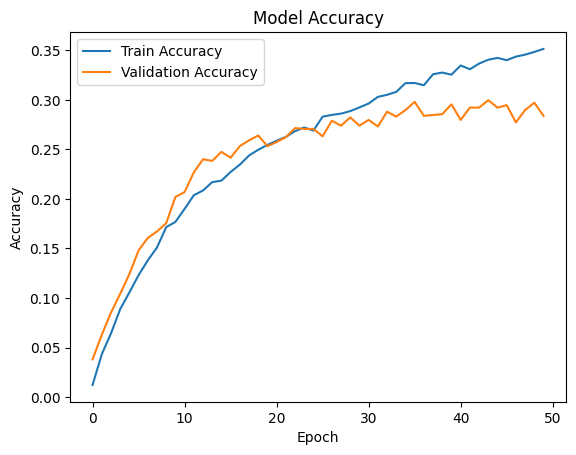

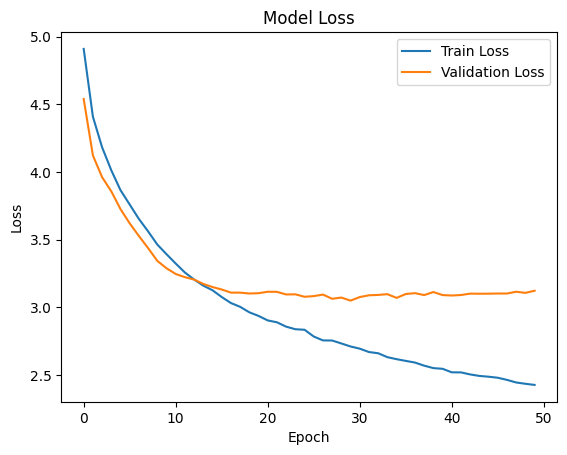

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


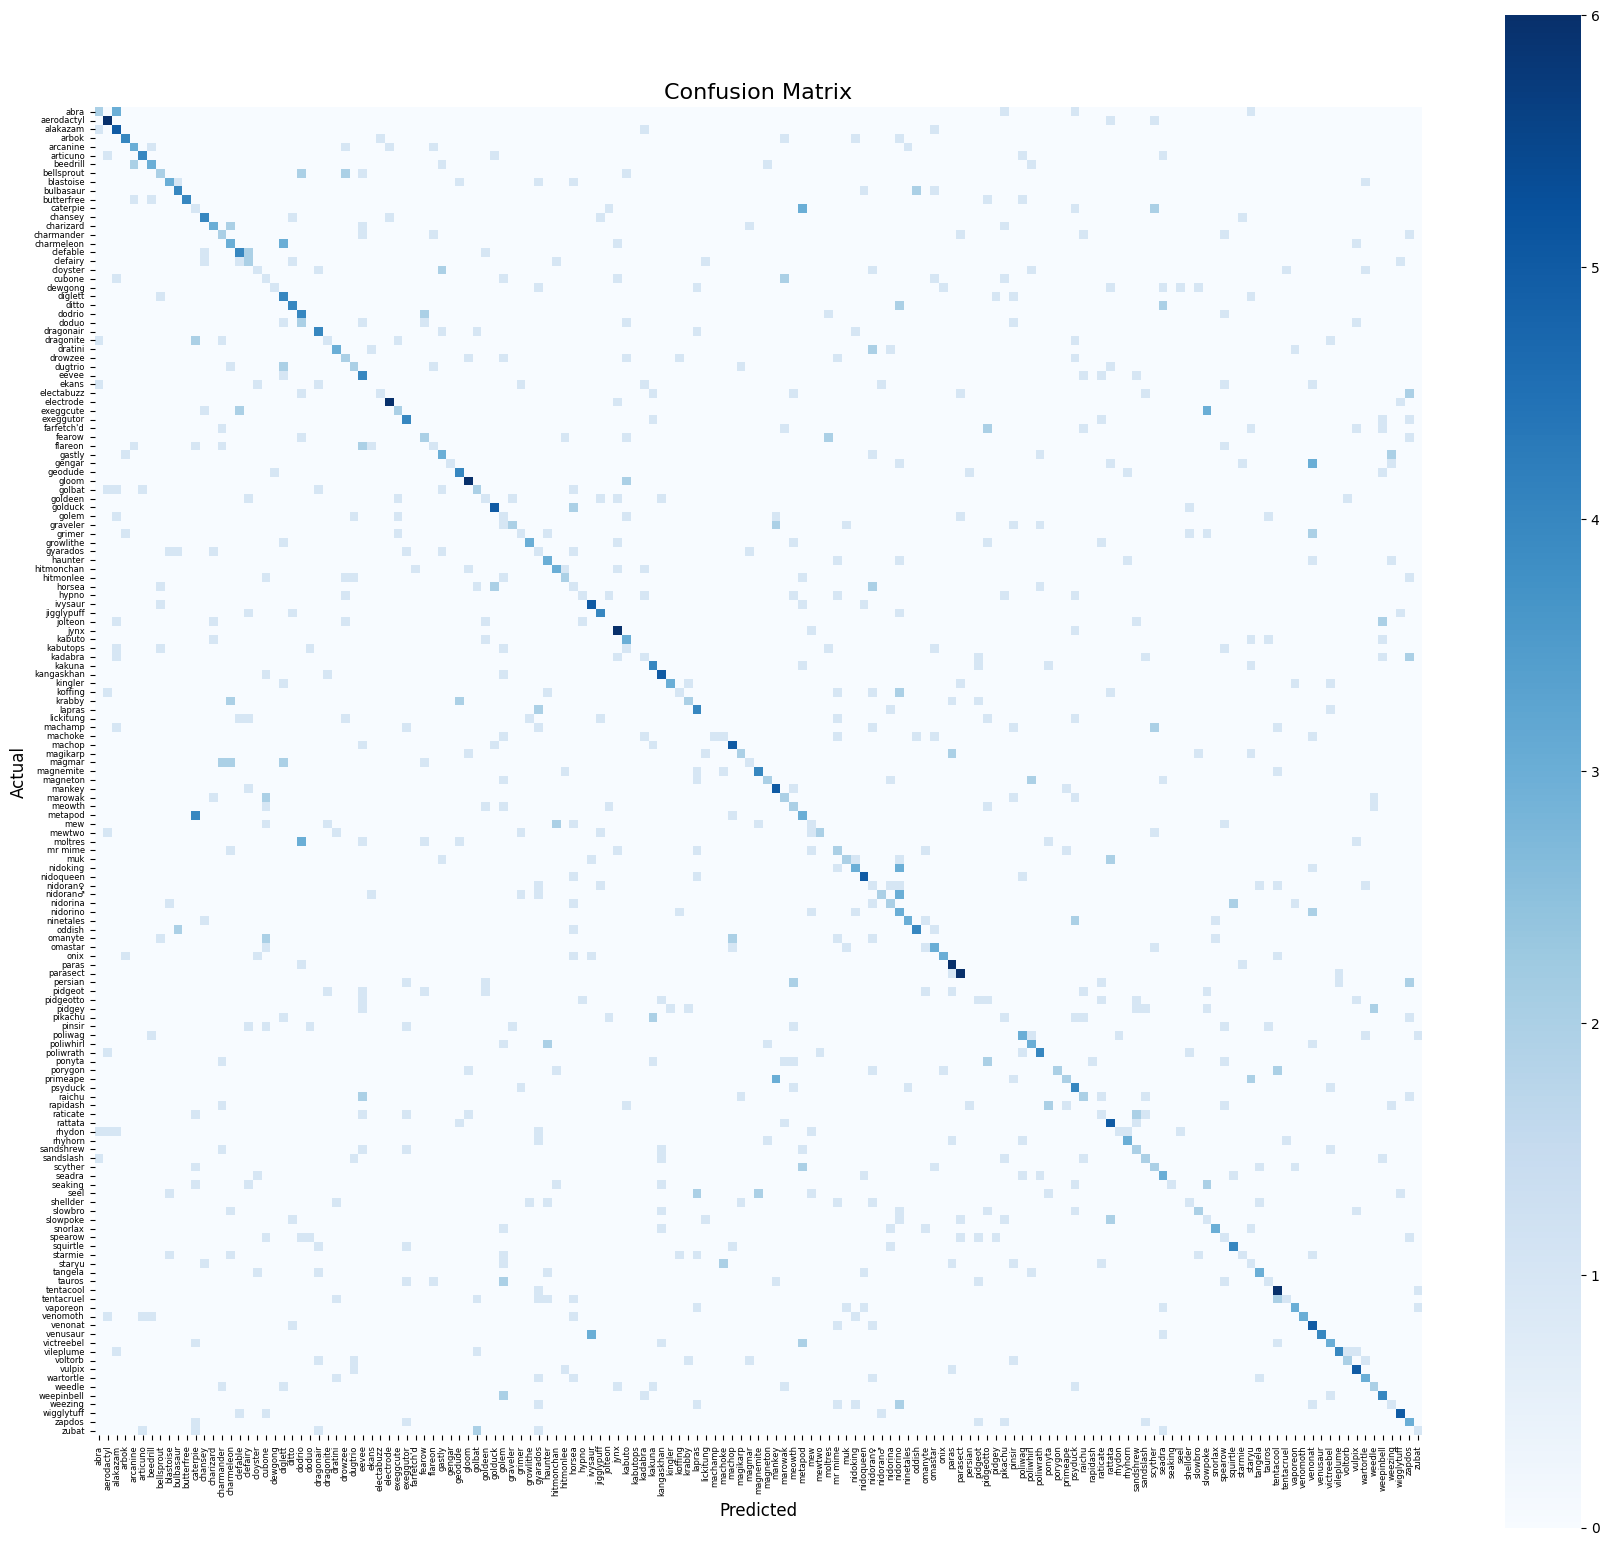

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.29      0.25      0.27         8
           1       0.46      0.75      0.57         8
           2       0.29      0.62      0.40         8
           3       0.57      0.50      0.53         8
           4       0.43      0.38      0.40         8
           5       0.57      0.50      0.53         8
           6       0.43      0.38      0.40         8
           7       0.29      0.25      0.27         8
           8       0.43      0.38      0.40         8
           9       0.50      0.50      0.50         8
          10       1.00      0.50      0.67         8
          11       0.07      0.12      0.09         8
          12       0.44      0.50      0.47         8
          13       0.43      0.38      0.40         8
          14       0.18      0.25      0.21         8
          15       0.23      0.38      0.29         8
          16       0.44      0.50      0.4

/Users/jessicawentworth/Documents/ML Group Project/pokemon-image-classification/environments/nn-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jessicawentworth/Documents/ML Group Project/pokemon-image-classification/environments/nn-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jessicawentworth/Documents/ML Group Project/pokemon-image-classification/environments/nn-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedM

Train: (39864, 12288)


/Users/jessicawentworth/Documents/ML Group Project/pokemon-image-classification/environments/nn-env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.0173 - loss: 4.8170 - val_accuracy: 0.0646 - val_loss: 4.2104
Epoch 2/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.0563 - loss: 4.2689 - val_accuracy: 0.1060 - val_loss: 3.9022
Epoch 3/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.0789 - loss: 4.0516 - val_accuracy: 0.1416 - val_loss: 3.6842
Epoch 4/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.1002 - loss: 3.9003 - val_accuracy: 0.1589 - val_loss: 3.5206
Epoch 5/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.1155 - loss: 3.7797 - val_accuracy: 0.1796 - val_loss: 3.4210
Epoch 6/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.1277 - loss: 3.6898 - val_accuracy: 0.1937 - val_loss: 3.3489
Epoch 7/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.1366 - loss: 3.6163 - val_accuracy: 0.2053 - val_loss: 3.2920
Epoch 8/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.1477 -

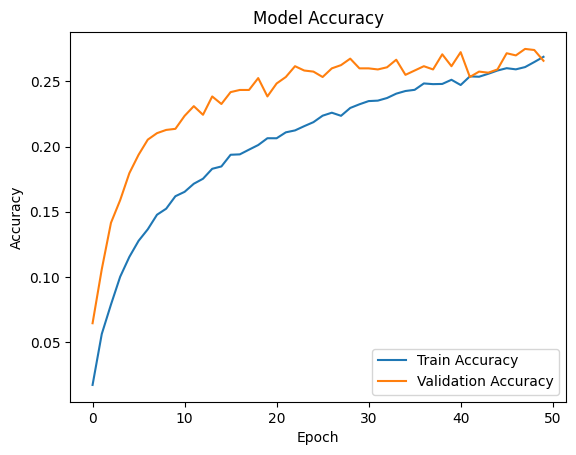

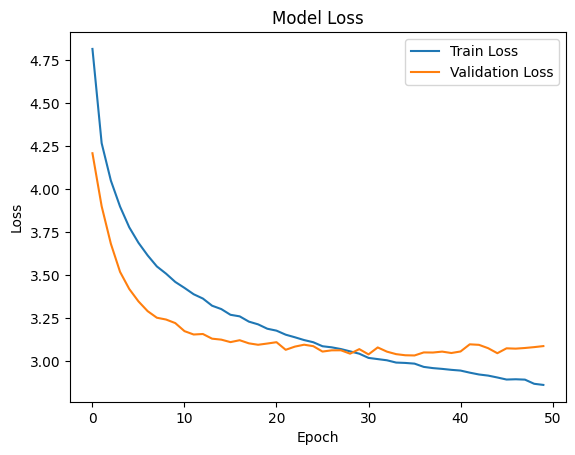

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


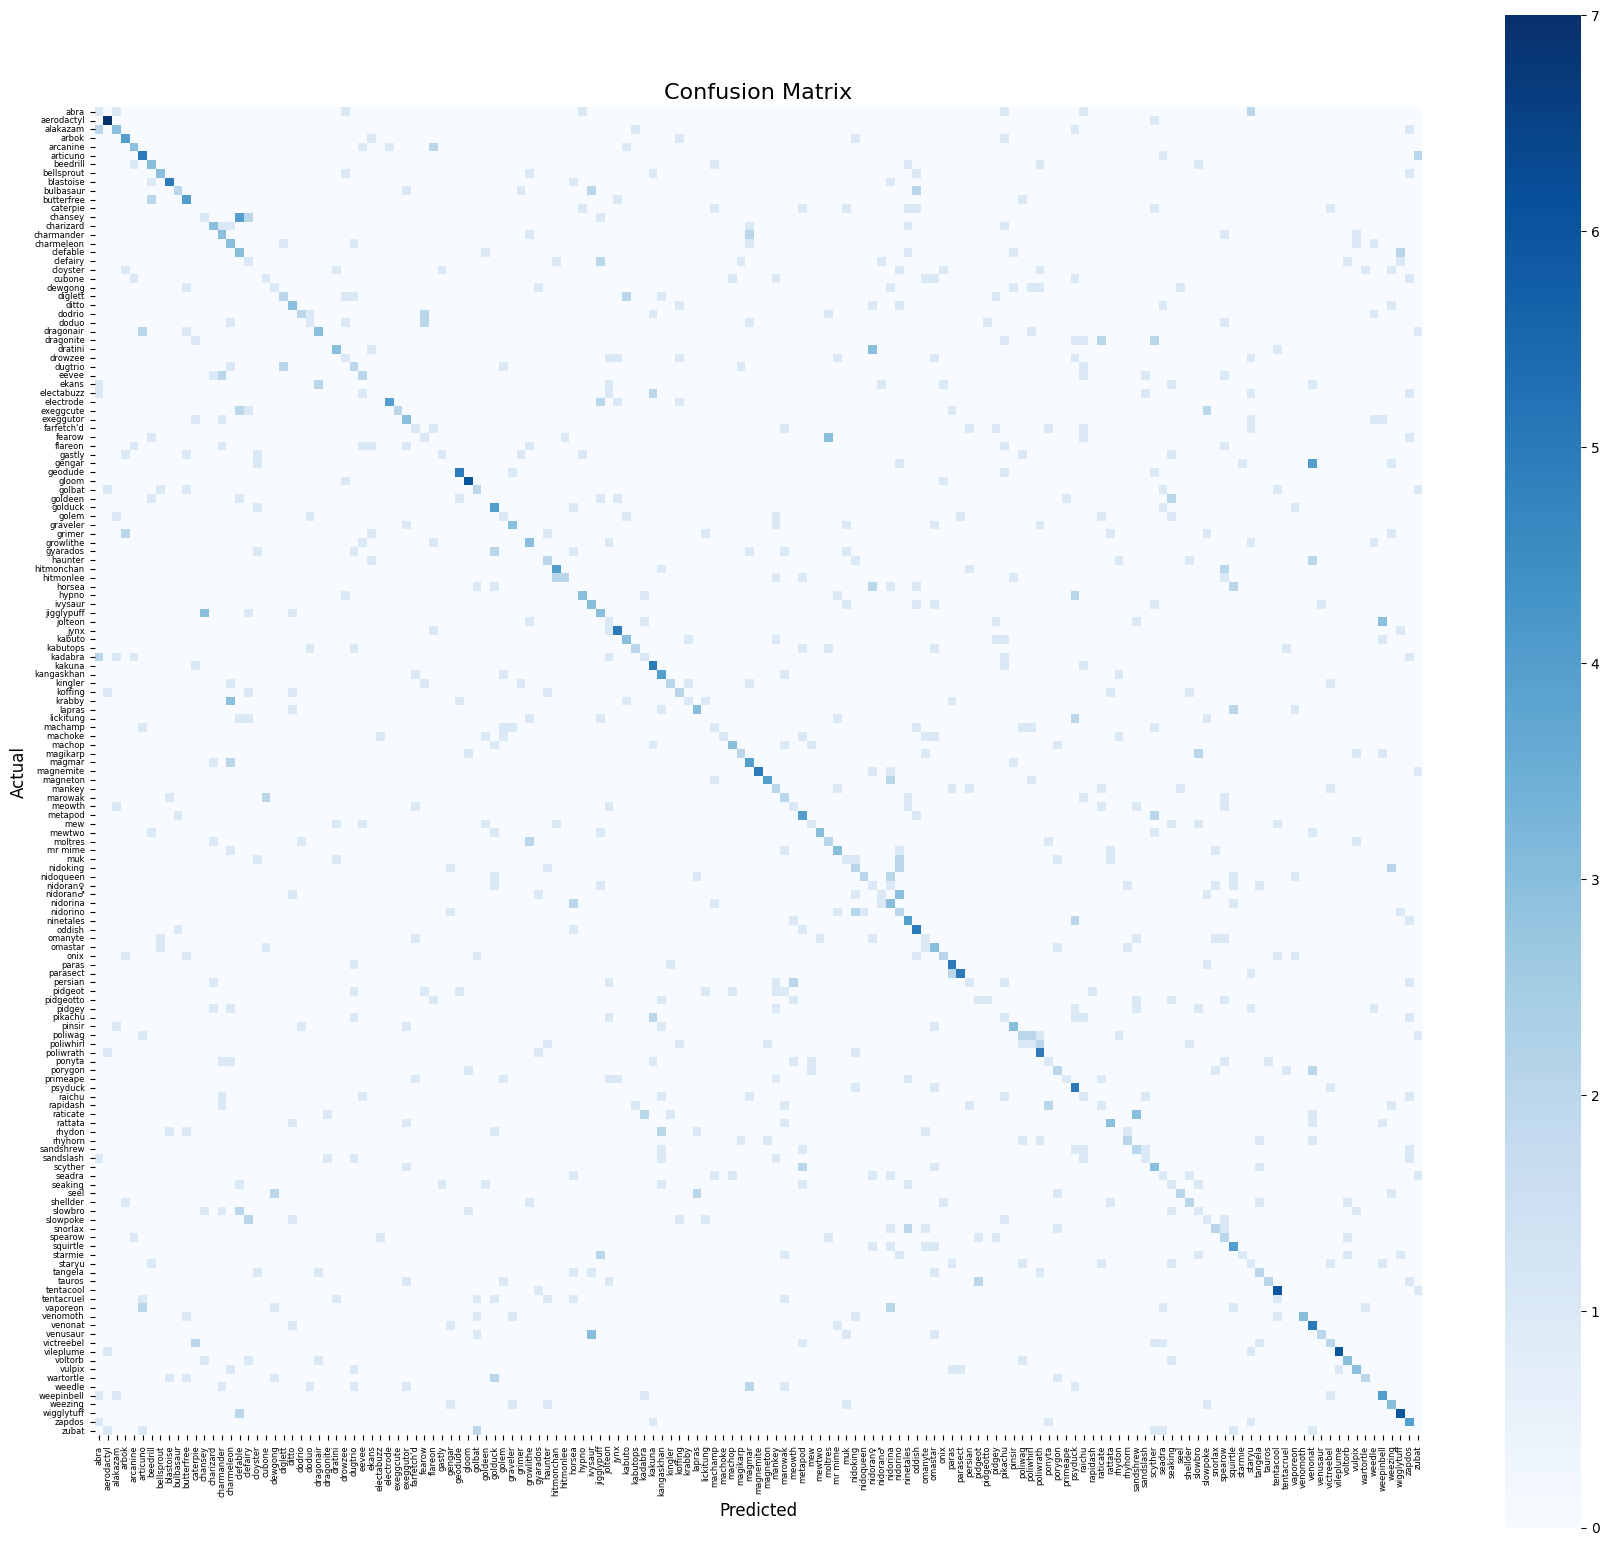

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.10      0.12      0.11         8
           1       0.58      0.88      0.70         8
           2       0.33      0.38      0.35         8
           3       0.40      0.50      0.44         8
           4       0.38      0.38      0.38         8
           5       0.38      0.62      0.48         8
           6       0.30      0.38      0.33         8
           7       0.50      0.38      0.43         8
           8       0.62      0.62      0.62         8
           9       0.50      0.25      0.33         8
          10       0.33      0.50      0.40         8
          11       0.00      0.00      0.00         8
          12       0.17      0.12      0.14         8
          13       0.38      0.38      0.38         8
          14       0.23      0.38      0.29         8
          15       0.19      0.38      0.25         8
          16       0.19      0.38      0.2

NameError: name 'pd' is not defined

In [ ]:
print("\nFinal Comparison:")
results = {}

for version in ["5aug", "10aug"]:
    model, history, acc, X_test, y_test, class_names, report, roc_auc = run_experiment(version)
    
    results[version] = {
    "accuracy": acc,
    "Validation Accuracy": max(history.history["val_accuracy"]),

    "macro_avg_precision": report["macro avg"]["precision"],
    "macro_avg_recall": report["macro avg"]["recall"],
    "macro_avg_f1-score": report["macro avg"]["f1-score"],
    "macro_avg_support": report["macro avg"]["support"],

    "weighted_avg_precision": report["weighted avg"]["precision"],
    "weighted_avg_recall": report["weighted avg"]["recall"],
    "weighted_avg_f1-score": report["weighted avg"]["f1-score"],
    "weighted_avg_support": report["weighted avg"]["support"],

    "ROC-AUC": roc_auc
}

    # PLOTS
    plot_training_history(history)
    plot_confusion_matrix(model, X_test, y_test, class_names)
    generate_classification_report(model, X_test, y_test)

nn_results_df = pd.DataFrame([
    {"Model": "Neural Network", "Dataset": "5aug", **results["5aug"]},
    {"Model": "Neural Network", "Dataset": "10aug", **results["10aug"]}
])

nn_results_df

nn_results_df.to_csv("nn_metrics.csv", index=False)

In [16]:
for k, v in results.items():
    print("\n", k)
    print(v)


 5aug
{'accuracy': 0.30960264801979065, 'Validation Accuracy': 0.2996688783168793, 'macro_avg_precision': 0.33222896757208104, 'macro_avg_recall': 0.30960264900662254, 'macro_avg_f1-score': 0.29810378251875286, 'macro_avg_support': 1208.0, 'weighted_avg_precision': 0.33222896757208104, 'weighted_avg_recall': 0.30960264900662254, 'weighted_avg_f1-score': 0.29810378251875286, 'weighted_avg_support': 1208.0, 'ROC-AUC': 0.9302752483443709}

 10aug
{'accuracy': 0.2798013389110565, 'Validation Accuracy': 0.27483442425727844, 'macro_avg_precision': 0.30036486117463296, 'macro_avg_recall': 0.27980132450331124, 'macro_avg_f1-score': 0.2692294067692742, 'macro_avg_support': 1208.0, 'weighted_avg_precision': 0.30036486117463296, 'weighted_avg_recall': 0.27980132450331124, 'weighted_avg_f1-score': 0.2692294067692742, 'weighted_avg_support': 1208.0, 'ROC-AUC': 0.9296709437086093}


In [17]:
print("Class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for i, count in zip(unique, counts):
    print(class_names[i], count)

Class distribution:
abra 8
aerodactyl 8
alakazam 8
arbok 8
arcanine 8
articuno 8
beedrill 8
bellsprout 8
blastoise 8
bulbasaur 8
butterfree 8
caterpie 8
chansey 8
charizard 8
charmander 8
charmeleon 8
clefable 8
clefairy 8
cloyster 8
cubone 8
dewgong 8
diglett 8
ditto 8
dodrio 8
doduo 8
dragonair 8
dragonite 8
dratini 8
drowzee 8
dugtrio 8
eevee 8
ekans 8
electabuzz 8
electrode 8
exeggcute 8
exeggutor 8
farfetch'd 8
fearow 8
flareon 8
gastly 8
gengar 8
geodude 8
gloom 8
golbat 8
goldeen 8
golduck 8
golem 8
graveler 8
grimer 8
growlithe 8
gyarados 8
haunter 8
hitmonchan 8
hitmonlee 8
horsea 8
hypno 8
ivysaur 8
jigglypuff 8
jolteon 8
jynx 8
kabuto 8
kabutops 8
kadabra 8
kakuna 8
kangaskhan 8
kingler 8
koffing 8
krabby 8
lapras 8
lickitung 8
machamp 8
machoke 8
machop 8
magikarp 8
magmar 8
magnemite 8
magneton 8
mankey 8
marowak 8
meowth 8
metapod 8
mew 8
mewtwo 8
moltres 8
mr mime 8
muk 8
nidoking 8
nidoqueen 8
nidoran♀ 8
nidoran♂ 8
nidorina 8
nidorino 8
ninetales 8
oddish 8
omanyte 8
om

The model was evaluated using accuracy, classification report, and confusion matrix. Accuracy provides an overall measure of correctness, while precision, recall, and F1-score give class-level performance insights.

A confusion matrix was used to visualize misclassifications between Pokémon classes. Additionally, reconstructed sample images confirmed that preprocessing steps preserved image quality and labels.

Training and validation curves were analyzed to assess model learning behavior and detect overfitting.

In [15]:
nn_results_df = pd.DataFrame([
    {"Model": "Neural Network", "Dataset": "5aug", **results["5aug"]},
    {"Model": "Neural Network", "Dataset": "10aug", **results["10aug"]}
])

nn_results_df

nn_results_df.to_csv("nn_metrics.csv", index=False)